# Computational and Variational Methods for Inverse Problems

## Assignment 2: Optimization methods and automatic differentiation

### (Notebook outline for problems 2, 3, and 4)

### Your name: Arushi R. Sadam


## Dependencies:

 - numpy
 - scipy
 - matplotlib
 - autograd (https://github.com/HIPS/autograd)

In [609]:
import autograd.numpy as np
from autograd import grad, jacobian

import matplotlib.pyplot as plt
from scipy import optimize

# 2) Discretized length and energy functionals

In this problem you will write code to compute the length function $L(u)$ and energy functional $E(u)$ from problem 1, for continuous piecewise linear functions $u:[0,1]\rightarrow \mathbb{R}$ with equally spaced nodes. We assume that $u$ has $N+2$ equally spaced nodes at locations
$$0, h, 2h, 3h, \dots, Nh, 1$$
and that $u$ takes specified values at the nodes, and is piecewise linear in the intervals ("cells") between these nodes.

## 2a) Spatial derivative of piecewise linear function
Let $u(x)$ be a continuous piecewise linear function on $[0,1]$, with $N+2$ equally spaced nodes (including endpoints). The spatial derivative $\frac{du}{dx}$ is piecewise constant on the $N+1$ cells between neighboring nodes. An example of this is shown below.

Text(0.5, 1.0, 'du/dx')

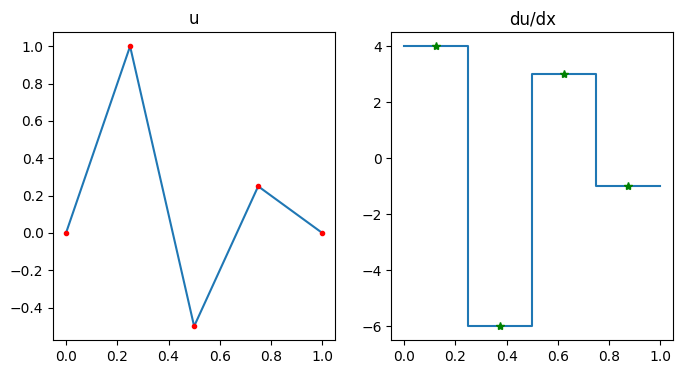

In [610]:
nodes = np.linspace(0.0, 1.0, 5)
u_at_nodes = np.array([0.0, 1.0, -0.5, 0.25, 0.0])

cell_centers = 0.5 * (nodes[1:] + nodes[:-1])
du_dx_in_cells = np.array([ 4., -6.,  3., -1.])

plt.figure(figsize=(8, 4))
plt.subplot(1,2,1)
plt.plot(nodes, u_at_nodes)
plt.plot(nodes, u_at_nodes, '.r')
plt.title('u')

plt.subplot(1,2,2)
plt.plot(nodes, np.concatenate([du_dx_in_cells, [-1]]), drawstyle='steps-post')
plt.plot(cell_centers, du_dx_in_cells, '*g')
plt.title('du/dx')

### Your task:
Write a function called "spatial\_derivative" that takes the length-$(N+2)$ vector of nodal values for $u$ as input, and returns the length-$N+1$ vector of cell values of $\frac{du}{dx}$ as output.

In [611]:
def spatial_derivative(u_at_nodes):
    h = 1/(len(u_at_nodes)-1)
    du_dx_in_cells = (u_at_nodes[1:] - u_at_nodes[0:-1])/h
    return du_dx_in_cells

### Test:
Error should be of close to machine epsilon (around $10^{-14}$ or smaller)

In [612]:
u = np.array([0.25, -0.66,  0.70, -0.41, -1.02, 0.57,  0.13, -1.27,  0.83, -1.21])
du_dx_true = np.array([-8.19,  12.24,  -9.99,  -5.49,  14.31,  -3.96, -12.6,  18.9, -18.36])

du_dx = spatial_derivative(u)
spatial_derivative_error = np.linalg.norm(du_dx - du_dx_true)
print('spatial_derivative_error=', spatial_derivative_error)

spatial_derivative_error= 5.7044291861996796e-15


## 2b) Arc length function

In Problem 1 you showed that the arc length of a function $u:[0,1]\rightarrow \mathbb{R}$ is given by
$$L(u) = \int_0^1 \sqrt{1 + \left(\frac{du}{dx}(x)\right)^2}~dx$$

### Your task:
Let $u$ be a continuous piecewise linear function on $[0,1]$, with $N+2$ equally spaced nodes, including endpoints (the same setup as in 2a). Write a function called "length\_functional" that takes the vector of $N+2$ nodal values of $u$ as input, and returns the arc length of $u$ as output.

#### Hint:
The integrand is a piecewise constant function.

In [613]:
def length_functional(u_at_nodes):
    # since u is piecewise linear, du/dx is piecewise constant
    h = 1/(len(u_at_nodes)-1)
    du_dx = spatial_derivative(u_at_nodes)

    L=np.sum(h*(np.ones(len(du_dx)) + du_dx**2)**.5)
    return L

### Test
Error should be of close to machine epsilon (around $10^{-14}$ or smaller)

In [614]:
xx = np.linspace(0.0, 1.0, 100)
u = np.sqrt(1.0 / 2.0 - np.power(xx - 0.5, 2))
L_true = 1.1107087105088733

L = length_functional(u)
length_functional_error = np.abs(L - L_true)
print('length_functional_error=', length_functional_error)

length_functional_error= 4.440892098500626e-16


## 2c) Energy functional

Let $u$ be the height of an idealized hanging chain, and for convenience let the linear density of the chain be $\rho=1/g$, where the $g$ is the gravitational constant. From Problem 1 we know that the potential energy functional for such a hanging chain is given by
$$E(u) = \int_0^1 u(x) ~ \sqrt{1 + \left(\frac{du}{dx}(x)\right)^2}~dx.$$

### Your task
Write a function named "energy\_functional" that takes as input the length $N+2$ vector of nodal values for a continuous piecewise linear function $u$ on $[0,1]$ as input (including values at the endpoints, as in 2a and 2b), and returns the energy functional $E(u)$ as output.

#### Hint:
The integrand is a **discontinuous** piecewise linear function because it is the product of a continuous piecewise linear function with a piecewise constant function.

In [615]:
def energy_functional(u_at_nodes):
    h = 1/(len(u_at_nodes)-1)
    du_dx = spatial_derivative(u_at_nodes)

    ds = h*(np.ones(len(du_dx)) + du_dx**2)**.5
    u_midpoint = (u_at_nodes[1:]+ u_at_nodes[:-1])/2 # avg u over element

    E = np.sum(u_midpoint*ds)
    return E

### Test
Error should be of close to machine epsilon (around $10^{-14}$ or smaller)

In [616]:
xx = np.linspace(0.0, 1.0, 75)
u = -np.sin(np.pi * xx)
E_true = -1.2379425688273515

E = energy_functional(u)
energy_functional_error = np.abs(E - E_true)
print('energy_functional_error=', energy_functional_error)

energy_functional_error= 0.0


# 3)  Objective function, Gradient, and Hessian

In problem 1 we saw that the hanging chain problem may be written as the following constrained optimization problem:

\begin{align}
\min_u &\quad E(u) \\
\text{such that} &\quad L(u) = L_0.
\end{align}

We may find approximate solutions to this problem by solving the following unconstrained optimization problem,
$$\min_u E(u) + \alpha (L(u) - L_0)^2$$
where we use a quadratic penalty to approximately enforce the constraint. Here $\alpha > 0$ is a penalty parameter; as $\alpha \rightarrow \infty$, the solution to the unconstrained optimization problem approaches the solution of the constrained optimization problem.

Let
$$J(u) := E(u) + \alpha (L(u) - L_0)^2$$
denote the unconstrained objective function. In this problem, you will implement this objective function for continuous piecewise linear functions with equally spaced nodes, and use **automatic differentiation** to compute the gradient of $J$, the Hessian of $J$, and matrix-vector products of the Hessian of $J$ with arbitrary vectors. You will also compare the gradient and Hessian of $J$ to approximate gradients and Hessians computed with finite differences with a variety of step sizes.

## Objective function
The objective function may be written as follows, using your energy and length functional code from the previous problem. Note that the objective function only operates on the $N$ interior nodes for $u$, since the endpoints of $u$ are fixed at zero.

In [617]:
def objective_function(u_at_interior_nodes, alpha, L0):
    u_at_nodes = np.hstack([np.array([0.0]),
                                     u_at_interior_nodes,
                                     np.array([0.0])])

    E = energy_functional(u_at_nodes)
    L = length_functional(u_at_nodes)
    J = E + alpha * np.power(L - L0, 2)
    return J

If you were unable to complete the previous problem, you may uncomment the following (intentionally obfsucated) implementation and use it instead:

In [618]:
# def objective_function(u_at_interior_vertices, alpha, L0):
#     u = np.concatenate([np.array([0]),
#                         u_at_interior_vertices,
#                         np.array([0])])
#     a = 1./(len(u)-1.)
#     b, c = (u[1:]-u[:-1])/a, 0.5*(u[1:] + u[:-1])
#     return a*np.sum(c*np.sqrt(1.+np.power(b,2)))+alpha*np.power(a*np.sum(np.sqrt(1.+np.power(b,2)))-L0,2)

## 3a) Gradient via automatic differentiation

Here we will use the "grad" function in the python automatic differentiation tool **autograd** to compute the gradient of your objective function. Here is a quick example of how to use it. More details can be found here:
https://github.com/HIPS/autograd/blob/master/docs/tutorial.md

### autodiff grad example

In [619]:
def f(x, a, b):
    return np.cos(a * x[0]) + np.sin(b * x[1])

grad_autodiff = grad(f, 0) # 0 indicates differentiation w.r.t. the first argument of f.

x = np.random.randn(2)
a = 1.3
b = -2.1
grad_at_x_autodiff = grad_autodiff(x, a, b)

grad_at_x_analytic = np.array([- a * np.sin(a * x[0]),
                                 b * np.cos(b * x[1])])

autodiff_error = np.linalg.norm(grad_at_x_analytic - grad_at_x_autodiff)
print('autodiff_error=', autodiff_error)

autodiff_error= 0.0


### Your task:
Use automatic differentiation to create a function named "compute\_gradient" that computes the gradient of the objective function, $g$, at a given $u$ for a given penalty parameter $\alpha$ and chain length $L_0$.

### Hint:
The code is a one-liner

In [620]:
# Construct the function compute_gradient(u_at_interior_nodes, alpha, L0)

####    VVVV   YOUR CODE GOES HERE    VVVV    ####


def compute_gradient(u_at_interior_nodes, alpha, L0):
    return grad(objective_function, 0)(u_at_interior_nodes, alpha, L0) # dphi/du







####    ^^^^   YOUR CODE GOES HERE    ^^^^    ####

### Finite difference check:
On one hand, the directional derivative of $J$ in direction $p$ may be computed from the gradient at $u$, $g(u)$, as follows:
$$\frac{d J}{d u}(u) p = g(u)^T p.$$
On the other hand, we may approximate the directional derivative via finite differences
$$\frac{d J}{du}(u) p \approx \frac{J(u + s p) - J(u)}{s}$$
where $s$ is some small scalar.

This allows us to check our gradient by choosing a random direction $p$, and comparing the result of computing $\frac{d J}{d u}(u) p$ in these two different ways.

The error should be roughly the same order of magnitude as the step size.

In [621]:
N = 53
alpha = 8.95
L0 = 2.13
u1 = np.random.randn(N)
J1 = objective_function(u1, alpha, L0)

p = np.random.randn(N)
s = 1e-7 # step size
u2 = u1 + s*p

J2 = objective_function(u2, alpha, L0)
dJ_du_p_diff = (J2 - J1) / s

g = compute_gradient(u1, alpha, L0)
dJ_du_p = np.dot(g, p)

grad_err = np.abs( (dJ_du_p - dJ_du_p_diff) / dJ_du_p_diff )
print('step size=', s, ', gradient finite difference error=', grad_err)

step size= 1e-07 , gradient finite difference error= 3.622868452261339e-07


## 3b) Gradient finite difference plot

It is good practice to check your gradient with finite difference checks for a wide range variety of step sizes $s$, and make a log-log plot of the finite difference error as a function of $s$. If your gradient is working correctly, the resulting plot should look like a 'V', where the error decreases linearly from $s=10^0$ until somewhere around $s=10^{-5}$ to $s=10^{-9}$, then goes up again and/or becomes jagged.

### Example finite difference plot

step size= 1.0 , example gradient finite difference error= 0.4652107905866249
step size= 0.1 , example gradient finite difference error= 0.09216980330092554
step size= 0.01 , example gradient finite difference error= 0.010149238491119546
step size= 0.001 , example gradient finite difference error= 0.0010252344894599763
step size= 0.0001 , example gradient finite difference error= 0.00010262765389684411
step size= 1e-05 , example gradient finite difference error= 1.0263860758738798e-05
step size= 1e-06 , example gradient finite difference error= 1.0261413528204764e-06
step size= 1e-07 , example gradient finite difference error= 1.0088026621868141e-07
step size= 1e-08 , example gradient finite difference error= 4.0369671773449635e-08
step size= 1e-09 , example gradient finite difference error= 4.2543696599415577e-07
step size= 1e-10 , example gradient finite difference error= 1.7749515668148262e-06
step size= 1e-11 , example gradient finite difference error= 2.0228498016805106e-05
step s

Text(0, 0.5, 'error')

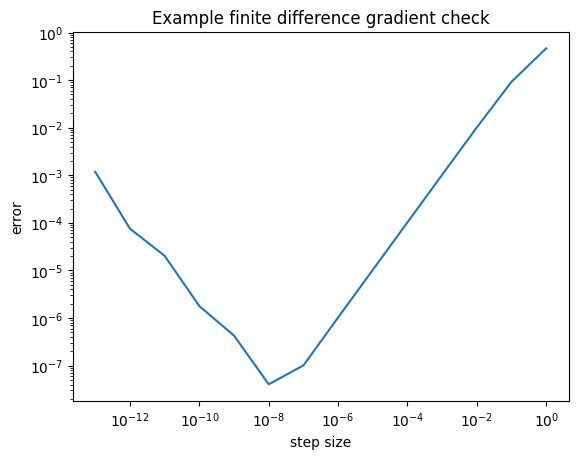

In [622]:
def f(x):
    return np.sin(x[0]) + np.cos(x[1])

def df_dx(x):
    return np.array([np.cos(x[0]), -np.sin(x[1])])

x1 = np.random.randn(2)
p = np.random.randn(2)
step_sizes = [1e0, 1e-1, 1e-2, 1e-3, 1e-4, 1e-5, 1e-6, 1e-7, 1e-8, 1e-9, 1e-10, 1e-11, 1e-12, 1e-13]

f1 = f(x1)
g1 = df_dx(x1)
df_dx_p = np.dot(g1, p)

grad_errs = list()
for s in step_sizes:
    x2 = x1 + s*p

    f2 = f(x2)
    df_dx_p_diff = (f2 - f1) / s

    grad_err = np.abs( (df_dx_p - df_dx_p_diff) / df_dx_p_diff )
    print('step size=', s, ', example gradient finite difference error=', grad_err)

    grad_errs.append(grad_err)

plt.loglog(step_sizes, grad_errs)
plt.title('Example finite difference gradient check')
plt.xlabel('step size')
plt.ylabel('error')

### Your task:
Perform finite difference checks on the hanging chain gradient for a wide range variety of step sizes $s$, and make a log-log plot of the finite difference error as a function of $s$. See 3a for an example of a finite difference check for a single step size.

step size= 1.0 , example gradient finite difference error= 0.7563605817106296
step size= 0.1 , example gradient finite difference error= 0.3674614314299045
step size= 0.01 , example gradient finite difference error= 0.025974839789025997
step size= 0.001 , example gradient finite difference error= 0.003457558590437115
step size= 0.0001 , example gradient finite difference error= 0.00035826479676161893
step size= 1e-05 , example gradient finite difference error= 3.595691759545863e-05
step size= 1e-06 , example gradient finite difference error= 3.5976709931647335e-06
step size= 1e-07 , example gradient finite difference error= 3.6121176477527627e-07
step size= 1e-08 , example gradient finite difference error= 1.4242299877368878e-08
step size= 1e-09 , example gradient finite difference error= 4.3832692922722295e-07
step size= 1e-10 , example gradient finite difference error= 6.472622460694125e-06
step size= 1e-11 , example gradient finite difference error= 2.671510177779454e-05
step size= 

Text(0, 0.5, 'error')

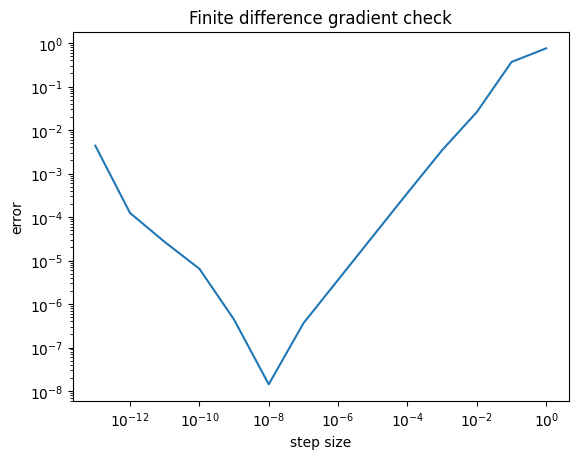

In [623]:
N = 53
alpha = 8.95
L0 = 2.13
u1 = np.random.randn(N)
p = np.random.randn(N)
step_sizes = [1e0, 1e-1, 1e-2, 1e-3, 1e-4, 1e-5, 1e-6, 1e-7, 1e-8, 1e-9, 1e-10, 1e-11, 1e-12, 1e-13]


# Make log-log plot of gradient finite difference error vs. step size

####    VVVV   YOUR CODE GOES HERE    VVVV    ####




f1 = objective_function(u1, alpha, L0)
g1 = compute_gradient(u1, alpha, L0)
df_dx_p = np.dot(g1, p)

grad_errs = list()
for s in step_sizes:
    u2 = u1 + s*p

    f2 = objective_function(u2,alpha,L0)
    df_dx_p_diff = (f2 - f1) / s

    grad_err = np.abs( (df_dx_p - df_dx_p_diff) / df_dx_p_diff )
    print('step size=', s, ', example gradient finite difference error=', grad_err)

    grad_errs.append(grad_err)

plt.loglog(step_sizes, grad_errs)
plt.title('Finite difference gradient check')
plt.xlabel('step size')
plt.ylabel('error')







####    ^^^^   YOUR CODE GOES HERE    ^^^^    ####

## 3c) Hessian-vector product via automatic differentiation

The Hessian is the derivative of the gradient, so the matrix-vector multiplication $H(u)p$ of the Hessian at $u$, $H(u)$, with a vector, $p$ is given by
$$H(u)p = \frac{d}{du} \left(\frac{d J}{du}(u) p\right) = \frac{d}{dp} \left(g(u)^T p\right).$$
In other words, $H(u) p$ is the gradient of the scalar-valued function
$$q(u) := g(u)^T p,$$
and this gradient may be calculated by automatic differentiation.

### Example:

In [624]:
def f(x, a, b):
    return np.cos(a * x[0]) + np.sin(b * x[1])

compute_grad_f = grad(f, 0)

def q(x, p, a, b):
    g = compute_grad_f(x, a, b)
    return np.dot(g, p)

hessian_vector_product_f = grad(q, 0)

a = 1.4
b = 4.1
x = np.random.randn(2)
p = np.random.randn(2)

Hp_autodiff = hessian_vector_product_f(x, p, a, b)

H_analytic = np.array([[-a*a*np.cos(a * x[0]),                     0],
                       [0,                     -b*b*np.sin(b * x[1])]])

Hp_analytic = np.dot(H_analytic, p)

hess_prod_err = np.linalg.norm(Hp_analytic - Hp_autodiff) / np.linalg.norm(Hp_analytic)
print('example hessian vector product error=', hess_prod_err)

example hessian vector product error= 1.4852593421062664e-16


### Your task:
Use autodiff's grad function to create a function named "compute\_hessian\_vector\_product" that computes the Hessian-vector product $H(u)p$.

In [625]:
# Construct the function compute_hessian_vector_product(u_at_interior_nodes, p_at_interior_nodes, alpha, L0)

compute_grad_f = grad(objective_function, 0)

def q(u_at_interior_nodes, p_at_interior_nodes, alpha, L0):
    g = compute_grad_f(u_at_interior_nodes, alpha, L0)
    return np.dot(g, p_at_interior_nodes)
def compute_hessian_vector_product(u_at_interior_nodes, p_at_interior_nodes, alpha, L0):
    return grad(q, 0)(u_at_interior_nodes, p_at_interior_nodes, alpha, L0)


### Finite difference check
The error should be roughly the same order of magnitude as the step size.

In [626]:
N = 53
alpha = 8.95
L0 = 2.13
u1 = np.random.randn(N)
G1 = compute_gradient(u1, alpha, L0)

p = np.random.randn(N)
s = 1e-7
u2 = u1 + s * p
G2 = compute_gradient(u2, alpha, L0)

Hp_diff = (G2 - G1) / s

Hp = compute_hessian_vector_product(u1, p, alpha, L0)

hessian_vector_product_error = np.linalg.norm(Hp - Hp_diff) / np.linalg.norm(Hp_diff)

print('s=', s, ', hessian vector product finite difference error=', hessian_vector_product_error)

s= 1e-07 , hessian vector product finite difference error= 5.500627342263574e-06


## 3d) Hessian-vector product finite difference check plot

### Your task:
Construct a log-log plot of the Hessian finite difference error for a wide variety of step sizes.

step size= 1.0 , Hessian finite difference error= 1.0603678844112967
step size= 0.1 , Hessian finite difference error= 0.21602789790608753
step size= 0.01 , Hessian finite difference error= 0.06010866564943245
step size= 0.001 , Hessian finite difference error= 0.006750545692817572
step size= 0.0001 , Hessian finite difference error= 0.0006832380211333105
step size= 1e-05 , Hessian finite difference error= 6.840662232512142e-05
step size= 1e-06 , Hessian finite difference error= 6.841317382738434e-06
step size= 1e-07 , Hessian finite difference error= 6.836907047447504e-07
step size= 1e-08 , Hessian finite difference error= 6.379778819668297e-08
step size= 1e-09 , Hessian finite difference error= 2.3436883965087692e-07
step size= 1e-10 , Hessian finite difference error= 2.6008705653180916e-06
step size= 1e-11 , Hessian finite difference error= 1.880278855342649e-05
step size= 1e-12 , Hessian finite difference error= 0.0002939642322001735
step size= 1e-13 , Hessian finite difference err

Text(0, 0.5, 'error')

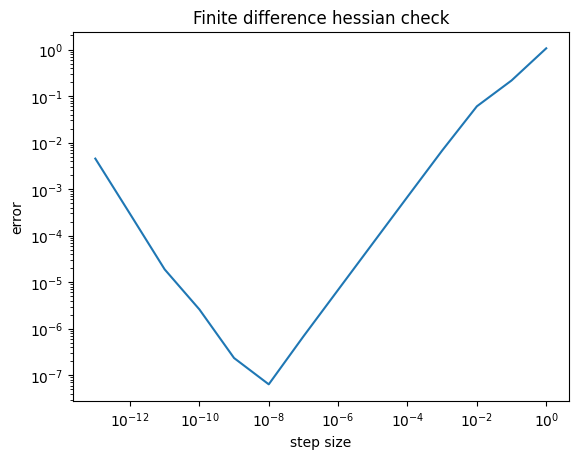

In [627]:
N = 53
alpha = 8.95
L0 = 2.13
u1 = np.random.randn(N)
p = np.random.randn(N)
step_sizes = [1e0, 1e-1, 1e-2, 1e-3, 1e-4, 1e-5, 1e-6, 1e-7, 1e-8, 1e-9, 1e-10, 1e-11, 1e-12, 1e-13]


# Make log-log plot of gradient finite difference error vs. step size




hessian_vector_product_error = list()
for s in step_sizes:
    u2 = u1 + s*p

    Hp = compute_hessian_vector_product(u1, p, alpha, L0)

    Hp_diff = 1/s * (compute_gradient(u2, alpha, L0)-compute_gradient(u1, alpha, L0))

    hessian_vp_error = np.linalg.norm(Hp - Hp_diff) / np.linalg.norm(Hp_diff)

    print('step size=', s, ', Hessian finite difference error=', hessian_vp_error)

    hessian_vector_product_error.append(hessian_vp_error)

plt.loglog(step_sizes, hessian_vector_product_error)
plt.title('Finite difference hessian check')
plt.xlabel('step size')
plt.ylabel('error')


### Comparison with dense Hessian

The dense $N \times N$ Hessian matrix is the Jacobian of the gradient, which can also be computed via automatic differentiation. This is not recommended for large problems.

Here we show how to compute the dense Hessian using the jacobian function in autograd.

In [628]:
compute_hessian = jacobian(compute_gradient, 0)

### Test dense Hessian
Error should be order machine epsilon (less than $10^{-14}$)

In [629]:
N = 15
alpha = 8.95
L0 = 2.13
u1 = np.random.randn(N)

H = compute_hessian(u1, alpha, L0)

p = np.random.randn(N)
Hp_dense = np.dot(H, p)
Hp = compute_hessian_vector_product(u1, p, alpha, L0)

dense_hessian_error = np.linalg.norm(Hp_dense - Hp) / np.linalg.norm(Hp)
print('dense_hessian_error=', dense_hessian_error)

dense_hessian_error= 5.879114765761698e-16


# 4) Comparison of optimization methods

In this problem, we will minimize $J$ using the method of steepest descent, BFGS, and the Newton-Conjugate-Gradient method. We will also plot convergence curves, and estimate the rate of convergence for these methods.

We will show you how to do this using BFGS as an example, and you will do this for steepest descent and Newton-CG.

### Problem parameters

For this problem, please use $N=32$, $L_0 = 3.0$, and $\alpha=1e2$.

In [630]:
N = 32
L0 = 3.0
alpha = 1e2

# Useful versions of the objective, gradient,
# and hessian-vector product functions
J_func = lambda u: objective_function(u, alpha, L0)
g_func = lambda u: compute_gradient(u, alpha, L0)
Hp_func = lambda u, p: compute_hessian_vector_product(u, p, alpha, L0)

### Initial guess

A reasonable initial guess is the parabola
$$u_0(x) = -C~ x(1-x)$$
with constant
$$C = 2 \left(L_0 - 1\right).$$
The constant $C$ is chosen to make the arc length of $u$ close to $L_0$. The formula for $C$ can be derived by approximating the arc length of the parabola with the length of box function that has the same minimum value.

In [631]:
xx_including_endpoints = np.linspace(0.0, 1.0, N+2)

C = -2.0 * (L0 - 1.0)
u0_including_endpoints = C * xx_including_endpoints * (1.0-xx_including_endpoints)
u0 = u0_including_endpoints[1:-1]

### Example: BFGS

In [632]:
u = u0.copy()
JJ_bfgs = list()
gradnorms_bfgs = list()
def callback(uk):
    JJ_bfgs.append(J_func(uk))
    gradnorms_bfgs.append(np.linalg.norm(g_func(uk)))

sol = optimize.minimize(J_func, u0, method='BFGS', jac=g_func, callback=callback, tol=1e-6)
print(sol)

u = sol.x

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: -2.1828846090868192
        x: [-2.380e-01 -4.379e-01 ... -4.379e-01 -2.380e-01]
      nit: 92
      jac: [ 1.754e-07 -7.389e-08 ... -1.260e-07  1.372e-07]
 hess_inv: [[ 3.928e+00  3.617e+00 ... -9.583e-02  4.197e-01]
            [ 3.617e+00  6.845e+00 ... -3.610e-01 -6.469e-02]
            ...
            [-9.583e-02 -3.610e-01 ...  7.106e+00  4.373e+00]
            [ 4.197e-01 -6.469e-02 ...  4.373e+00  4.715e+00]]
     nfev: 103
     njev: 103


### BFGS: check that solution gradient is small and plot the solution

||g(u)|| / ||g(u_0)||= 2.5028482237130585e-08


Text(0, 0.5, 'u(x)')

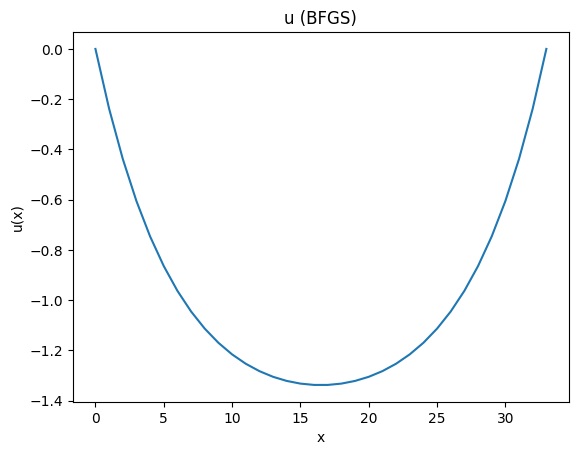

In [633]:
norm_g0 = np.linalg.norm(g_func(u0))
norm_g = np.linalg.norm(g_func(u))
print('||g(u)|| / ||g(u_0)||=', norm_g / norm_g0) # should be less than 1e-6

u_including_endpoints = np.concatenate([[0], u, [0]])

plt.figure()
plt.plot(u_including_endpoints)
plt.title('u (BFGS)')
plt.xlabel('x')
plt.ylabel('u(x)')

## Plot convergence of $J - J_*$ for BFGS

 We use the last value of $J$ as a proxy for the solution $J_*$.

Text(0.5, 0, '$k$')

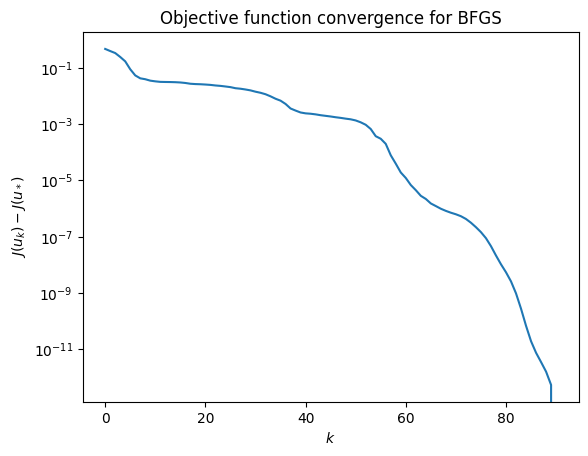

In [634]:
plt.semilogy(JJ_bfgs[1:] - JJ_bfgs[-1])
plt.title('Objective function convergence for BFGS')
plt.ylabel('$J(u_k) - J(u_*)$')
plt.xlabel('$k$')

### BFGS: estimate convergence rate

Asymptotically, the error should decrease as
$$||g(u_{k+1})|| \le c ||g(u_{k})||^q$$
for some constant $c$ and convergence rate $q$, where $u_*$ is the solution to the optimization problem.

We can estimate the convergence rate, $q$, by plotting $||g(u_{k+1})||$ vs. $||g(u_{k})||$ on a log-log plot and finding the slope.

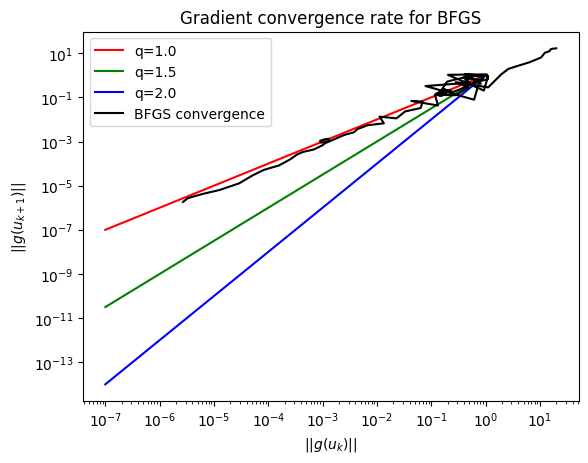

In [635]:
xx = np.logspace(-7, 0, 13)
yy10 = np.power(xx, 1.0)
yy15 = np.power(xx, 1.5)
yy20 = np.power(xx, 2.0)
plt.loglog(xx, yy10,'r')
plt.loglog(xx, yy15,'g')
plt.loglog(xx, yy20,'b')

plt.loglog(gradnorms_bfgs[:-1], gradnorms_bfgs[1:],'k')
plt.title('Gradient convergence rate for BFGS')
plt.ylabel('$||g(u_{k+1})||$')
plt.xlabel('$||g(u_k)||$')
plt.legend(['q=1.0', 'q=1.5', 'q=2.0', 'BFGS convergence'])

## 4a) Steepest descent

The method of steepest descent minimizes the function $J(u)$ via the iteration
$$u_{k+1} = u_k - \beta
_kg(u_k)$$
where $u_k$ is the $k\text{th}$ iterate, $g(u_k)$ is the gradient at the $k\text{th}$ iterate, and $\beta_k$ is a step size parameter.

### Your task:

Minimize $J$ using the method of steepest descent. You should write your own steepest descent code for this (do not use existing steepest descent libraries).

Continue iterating until $||g_k|| < 10^{-6} ||g_0||$ or smaller. This should require several thousand iterations.

Save the function values $J(u_k)$ for all iterations so we can plot the convergence.


#### Hint: step size

The trick here is choosing $\beta_k$. If $\beta_k$ is too large, the method may become unstable and diverge. If $\beta_k$ is too small, the method will converge slowly.

A popular option is to choose a step length satisfying the Wolfe conditions:

https://en.wikipedia.org/wiki/Wolfe_conditions

You may use the function scipy.optimize.line_search to find a step length satisfying these conditions:

https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.line_search.html#scipy.optimize.line_search

In [636]:
J_func(u0)

44.596635795767156

In [637]:
from scipy.optimize import line_search
u = u0.copy() # update u each iteration

J0 = J_func(u)
g0 = g_func(u)
norm_g0 = np.linalg.norm(g0)

JJ_sd = list()
JJ_sd.append(J0) # Keep appending the value of J to this list each iteration

gradnorms_sd = list()
gradnorms_sd.append(norm_g0) # keep appending the value of ||g|| each iteration


# Solve optimization problem using method of steepest descent.

epsilon = norm_g0*10**(-6) # some tolerance
gk = g0
maxiter = 10000 ### just for testing convergence
iter=0
while np.linalg.norm(gk) > epsilon and iter<maxiter:
    gk = g_func(u)
    pk = -gk

    alpha_k = line_search(J_func, g_func, u, pk)[0]

    gradnorms_sd.append(np.linalg.norm(gk))

    u += alpha_k*pk
    JJ_sd.append(J_func(u))
    iter+=1

# Now the solution should be in the variable u
# and JJ_sd should be a list, with JJ[k] = J(u_k)

JJ_sd = np.array(JJ_sd) # Make JJ_sd into array instead of list
gradnorms_sd = np.array(gradnorms_sd)

### Test:

||g(u)|| / ||g(u_0)||= 2.418501590157732e-06


Text(0, 0.5, 'u(x)')

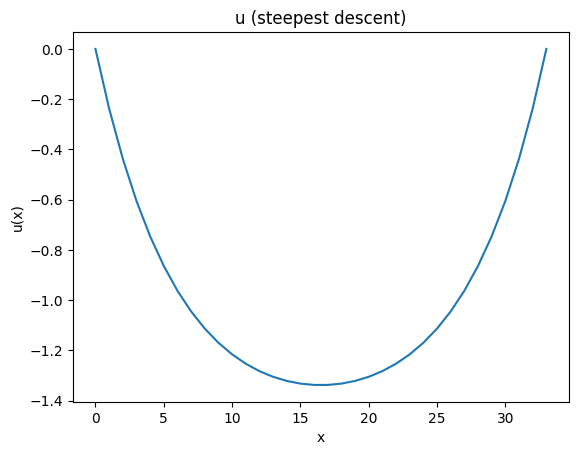

In [638]:
norm_g = np.linalg.norm(g_func(u))
print('||g(u)|| / ||g(u_0)||=', norm_g / norm_g0) # should be less than 1e-6

u_including_endpoints = np.concatenate([[0], u, [0]])

plt.figure()
plt.plot(u_including_endpoints)
plt.title('u (steepest descent)')
plt.xlabel('x')
plt.ylabel('u(x)')

## Plot convergence of $J - J_*$ for steepest descent

 Use the last value of $J$ as a proxy for the solution $J_*$.

Text(0.5, 0, '$k$')

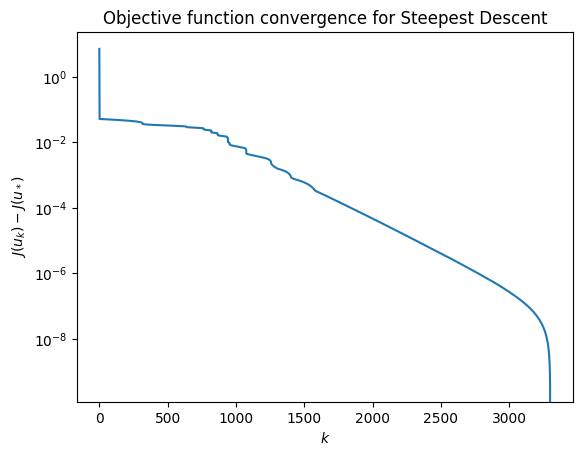

In [639]:
# Make a semilogy plot of Jk - J* vs. k for steepest descent

####    VVVV   YOUR CODE GOES HERE    VVVV    ####


plt.semilogy(JJ_sd[1:] - JJ_sd[-1])
plt.title('Objective function convergence for Steepest Descent')
plt.ylabel('$J(u_k) - J(u_*)$')
plt.xlabel('$k$')



####    ^^^^   YOUR CODE GOES HERE    ^^^^    ####

## 4b) Steepest descent convergence rate

Asymptotically, the error should decrease as
$$||g(u_{k+1})|| \le c ||g(u_{k})||^q$$
for some constant $c$ and convergence rate $q$, where $u_*$ is the solution to the optimization problem.

### Your task:

Estimate the convergence rate, $q$, by plotting $||g(u_{k+1})||$ vs. $||g(u_{k})||$ on a log-log plot and finding the slope.

Note: the curve may be fuzzy because of oscillatory overshooting in gradient descent.

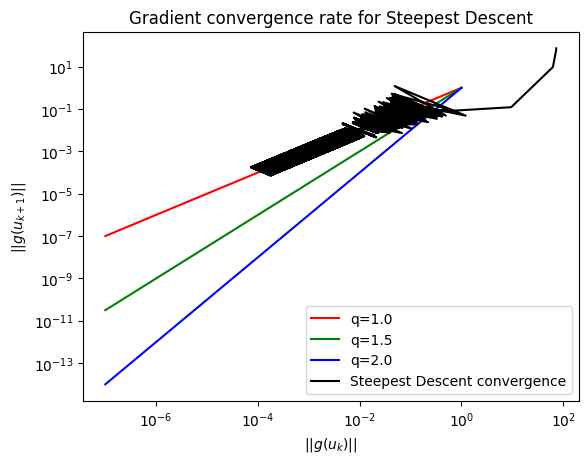

In [640]:
# Make a loglog plot of ||g_(k+1)|| vs. ||g_k|| for steepest descent

xx = np.logspace(-7, 0, 13)
yy10 = np.power(xx, 1.0)
yy15 = np.power(xx, 1.5)
yy20 = np.power(xx, 2.0)
plt.loglog(xx, yy10,'r')
plt.loglog(xx, yy15,'g')
plt.loglog(xx, yy20,'b')

plt.loglog(gradnorms_sd[:-1], gradnorms_sd[1:],'k')
plt.title('Gradient convergence rate for Steepest Descent')
plt.ylabel('$||g(u_{k+1})||$')
plt.xlabel('$||g(u_k)||$')
plt.legend(['q=1.0', 'q=1.5', 'q=2.0', 'Steepest Descent convergence'])


Steepest descent has a linear convergence rate; $q \approx 1.$

## 4c) Newton-CG

### Your task:

Minimize $J$ uising the Newton-CG method implemented in scipy.optimize.minimize:
https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.minimize.html#scipy.optimize.minimize

https://docs.scipy.org/doc/scipy/reference/optimize.minimize-newtoncg.html

 - Use a tolerance of $10^{-6}$

 - Save the intermediate values of $J(u_k)$ so that we can study convergence.


### Hint:
To save intermediate values of $J(u_k)$, use a "callback" function.

In [641]:
J_func(u0)

44.596635795767156

In [642]:
u = u0.copy()
JJ_ncg = list()
gradnorms_ncg = list()
def callback(uk):
    JJ_ncg.append(J_func(uk))
    gradnorms_ncg.append(np.linalg.norm(g_func(uk)))

# sol = optimize.minimize(####    YOUR CODE HERE    ####)

sol = optimize.minimize(J_func, u0, method='Newton-CG', jac=g_func, hessp=Hp_func, callback=callback, tol=1e-6)
print(sol)

u = sol.x

 message: Optimization terminated successfully.
 success: True
  status: 0
     fun: -2.182884609087086
       x: [-2.380e-01 -4.379e-01 ... -4.379e-01 -2.380e-01]
     nit: 27
     jac: [-1.715e-07 -7.566e-08 ... -7.811e-08 -1.648e-07]
    nfev: 36
    njev: 36
    nhev: 267


### Test

||g(u)|| / ||g(u_0)||= 1.7161267772856787e-10


Text(0, 0.5, 'u(x)')

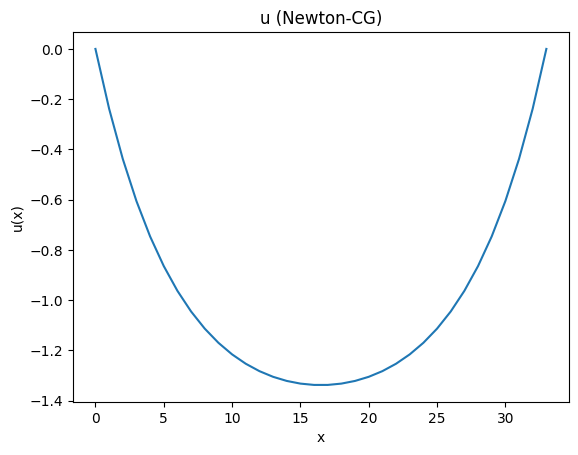

In [643]:
norm_g = np.linalg.norm(g_func(u))
print('||g(u)|| / ||g(u_0)||=', norm_g / norm_g0) # should be less than 1e-6

u_including_endpoints = np.concatenate([[0], u, [0]])

plt.figure()
plt.plot(u_including_endpoints)
plt.title('u (Newton-CG)')
plt.xlabel('x')
plt.ylabel('u(x)')

## Plot convergence of $J - J_*$ for Newton-CG

 Use the last value of $J$ as a proxy for the solution $J_*$.

Text(0.5, 0, '$k$')

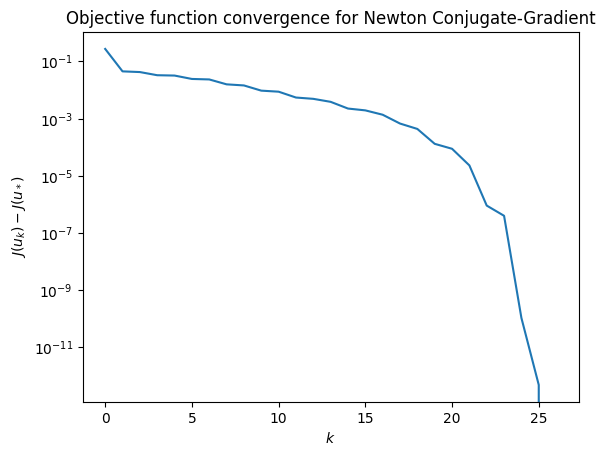

In [644]:
# Make a semilogy plot of Jk - J* vs. k for Newton-CG

plt.semilogy(JJ_ncg - JJ_ncg[-1])
plt.title('Objective function convergence for Newton Conjugate-Gradient')
plt.ylabel('$J(u_k) - J(u_*)$')
plt.xlabel('$k$')



## 4d) Newton-CG convergence

Asymptotically, the error should decrease as
$$||g(u_{k+1})|| \le c ||g(u_{k})||^q$$
for some constant $c$ and convergence rate $q$, where $u_*$ is the solution to the optimization problem.

### Your task:

Estimate the convergence rate, $q$, by plotting $||g(u_{k+1})||$ vs. $||g(u_{k})||$ on a log-log plot and finding the slope.

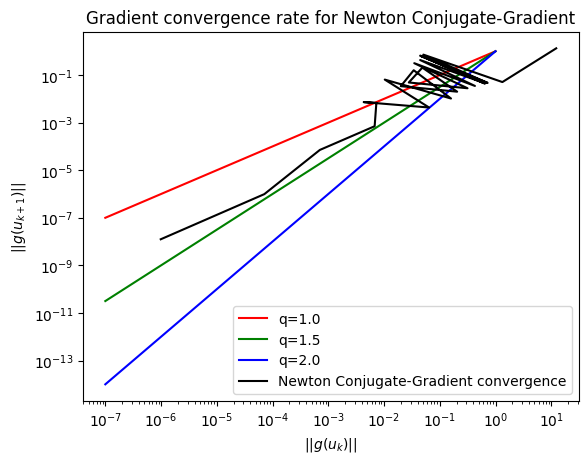

In [645]:
# Make a semilogy plot of Jk - J* vs. k for Newton-CG

####    VVVV   YOUR CODE GOES HERE    VVVV    ####



# Make a loglog plot of ||g_(k+1)|| vs. ||g_k|| for steepest descent

xx = np.logspace(-7, 0, 13)
yy10 = np.power(xx, 1.0)
yy15 = np.power(xx, 1.5)
yy20 = np.power(xx, 2.0)
plt.loglog(xx, yy10,'r')
plt.loglog(xx, yy15,'g')
plt.loglog(xx, yy20,'b')


# plt.scatter(10**-3,10,color = "cyan")
plt.loglog(gradnorms_ncg[:-1], gradnorms_ncg[1:],'k')
plt.title('Gradient convergence rate for Newton Conjugate-Gradient')
plt.ylabel('$||g(u_{k+1})||$')
plt.xlabel('$||g(u_k)||$')
plt.legend(['q=1.0', 'q=1.5', 'q=2.0', 'Newton Conjugate-Gradient convergence'])





####    ^^^^   YOUR CODE GOES HERE    ^^^^    ####

The convergence rate of the Newton Conjugate Gradient method is between 1 and 1.5. This is indicative of a superlinear convergence rate, so, the forcing term $\eta_k = min(0.5, \sqrt{\|g_k\|})$, where $g_k$ is the gradient at the $k^{th}$ CG iteration.

### Efficiency of Newton CG vs BFGS and Steepest Descent
In general, the Newton conjugate-gradient method provides linear, superlinear, or quadratic convergence based on the choice of the forcing term $\eta_k$. In the SciPy implementation, we notice a superlinear convergence rate. Meanwhile, in this example, the quasi-Newton method BFGS displays an approximately linear convergence rate (in general, BFGS should provide a superlinear or fast linear convergence). Finally, steepest descent provides the worst convergence rate, linear. Thus, the Newton CG is the most efficient optimization choice.


## Problem 5: mesh independence and mesh continuation


### 5a: SD on mesh independence

In [646]:
def u_init(N):
    xx_including_endpoints = np.linspace(0.0, 1.0, N+2)

    C = -2.0 * (L0 - 1.0)
    u0_including_endpoints = C * xx_including_endpoints * (1.0-xx_including_endpoints)
    u0 = u0_including_endpoints[1:-1]
    return u0

Text(0.5, 1.0, 'Mesh Dependence in Steepest Descent Convergence')

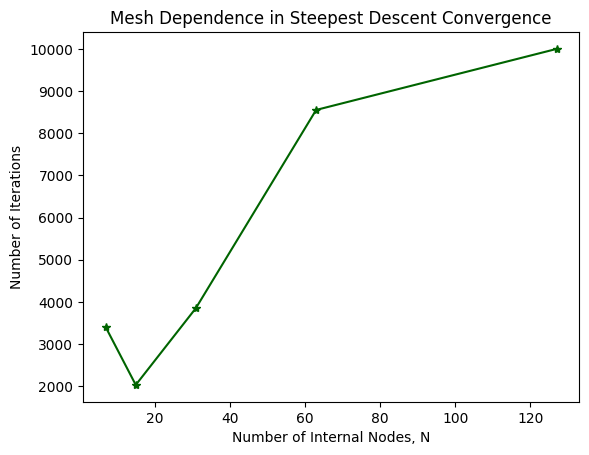

In [647]:



def sd(u):
    J0 = J_func(u)
    g0 = g_func(u)
    norm_g0 = np.linalg.norm(g0)

    JJ_sd = list()
    JJ_sd.append(J0) # Keep appending the value of J to this list each iteration

    gradnorms_sd = list()
    gradnorms_sd.append(norm_g0) # keep appending the value of ||g|| each iteration

    # Solve optimization problem using method of steepest descent.
    epsilon = norm_g0*10**(-6) # some tolerance
    gk = g0

    maxiter = 10000 ### just for testing convergence
    i=0
    while np.linalg.norm(gk) > epsilon and i<maxiter:
        gk = g_func(u)
        pk = -gk

        alpha_k = line_search(J_func, g_func, u, pk)[0]

        u += alpha_k*pk
        JJ_sd.append(J_func(u))
        gradnorms_sd.append(np.linalg.norm(gk))

        i+=1

    # Now the solution should be in the variable u
    # and JJ_sd should be a list, with JJ[k] = J(u_k)

    JJ_sd = np.array(JJ_sd) # Make JJ_sd into array instead of list
    gradnorms_sd = np.array(gradnorms_sd)
    return u, JJ_sd, gradnorms_sd, i

iterations = []
Ns = []
for p in range(5):
    N = 8*2**p - 1
    u = u_init(N)
    u_opt, JJ_sd, gradnorms_sd,iter = sd(u)
    iterations+=[iter]
    Ns += [N]
plt.plot(Ns, iterations,"*-", color = "darkgreen")
plt.ylabel("Number of Iterations")
plt.xlabel("Number of Internal Nodes, N")
plt.title("Mesh Dependence in Steepest Descent Convergence")


Per the above graph, we can conclude that steepest descent does not exhibit mesh independence; in general, for a more refined mesh, steepest descent requires more iterations to achieve convergence.

### 5b: Newton CG mesh independence

Text(0.5, 1.0, 'Mesh Independence in Newton Conjugate-Gradient Convergence')

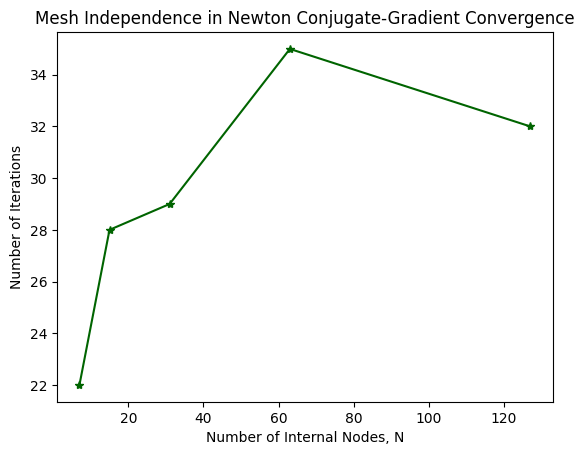

In [648]:

def ncg(u):
    sol = optimize.minimize(J_func, u, method='Newton-CG', jac=g_func, hessp=Hp_func, callback=callback, tol=1e-6)
    return sol.nit, sol.x

iterations = []
Ns = []
for p in range(5):
    N = 8*2**p - 1
    u = u_init(N)
    niter, solval = ncg(u)
    iterations+=[niter]
    Ns += [N]

plt.plot(Ns, iterations,"*-", color = "darkgreen")
plt.ylabel("Number of Iterations")
plt.xlabel("Number of Internal Nodes, N")
plt.title("Mesh Independence in Newton Conjugate-Gradient Convergence")


In [649]:
iterations

[22, 28, 29, 35, 32]

Per the above graph, we can conclude that Newton CG uses a relatively constant number of iterations (at least compared to steepest descent) as the mesh is refined. While steepest descent experienced ~500% increase in iterations as the internal nodes increased from 8 to 128, Newton CG only experienced a max difference of 20-30% (as the mesh was refined).

### 5c: Newton CG + mesh interpolation

Text(0.5, 1.0, 'Mesh Independence in Newton Conjugate-Gradient Convergence')

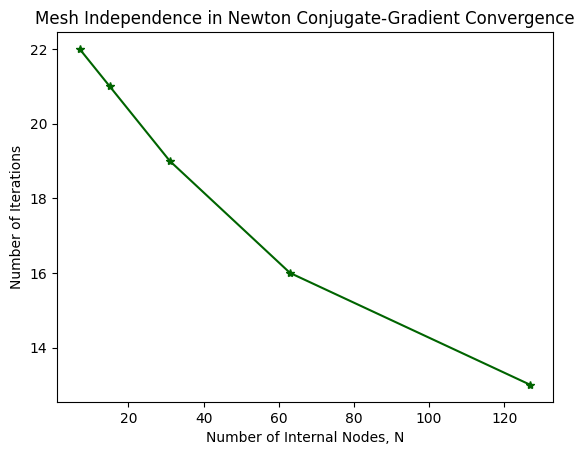

In [ ]:

def ncg_full(u, tolerance=1e-6):
    sol = optimize.minimize(J_func, u, method='Newton-CG', jac=g_func, hessp=Hp_func, callback=callback, tol=tolerance)
    return sol.x, sol.nit, sol.njev

iterations = []
Ns = []
for p in range(6):
    N = 8*2**p - 1
    if p ==0: # init u per parabolic
        u = u_init(N)
    else: # intrapolate u
        dh = 1/(Ns[-1]+1)
        new_dh = 1/(N+1)
        x_old = np.linspace(0+dh, 1-dh, len(solution))  # Old grid points
        x_new = np.linspace(0+new_dh, 1-new_dh, N)  # New grid points
        u = np.interp(x_new, x_old, solution)

    solution, niter, njev = ncg_full(u)
    iterations+=[niter]
    Ns += [N]

#remember for each N, the previous iterations also count
# totaliterations=[]
# for s in range(len(iterations)):
#     totaliterations += [np.sum(iterations[:s]) ]
totaliterations = iterations
plt.plot(Ns, totaliterations,"*-", color = "darkgreen")
plt.ylabel("Number of Iterations")
plt.xlabel("Number of Internal Nodes, N")
plt.title("Mesh Independence in Newton Conjugate-Gradient Convergence")


In [651]:
iterations

[22, 21, 19, 16, 13]

When using the interpolated solution as an initial starting guess for the refined mesh solution, the number of iterations (from one mesh size to a finer mesh) is approximately constant (or slightly decreasing).
Compared to 5a (steepest descent), as in 5b, Newton CG with mesh interpolation shows a much faster and scalable rate of convergence (fewer iterations).

In problem 5b, Newton CG uses parabolic initial solution, and requires approximately 30 iterations to converge at any given mesh size. As shown in 5c, if an initial guess (via interpolation of a solution at lower mesh refinement) is used, then, convergence is much faster (~ 15 iterations). However, if counting the total number of Newton iterations to achieve convergence on a fine mesh, for the provided mesh sizes (and refinement steps), Newton CG without mesh interpolation (direct application on a fine mesh) is more efficient.

### Further analysis: 5b vs 5c

## Mesh Interpolation and Initial Solution Quality

Mesh interpolation to achieve a "good" initial solution is commonly used. However, in the above example, mesh interpolation actually *increases* the number of total iterations (for convergence on a fine mesh) compared to a direct solution.

This may be due to the simplistic nature of the solution—a hyperbolic cosine equation. Consider the taylor serie expansion of hyperbolic cosine (about $x = 0$):

$\cosh(x) = \sum_{n=0}^{\infty} \frac{x^{2n}}{(2n)!} = 1 + \frac{x^2}{2!} + \frac{x^4}{4!} + \frac{x^6}{6!} + \mathcal{O}(x^8)$

Note that the first nontrivial term after the constant is quadratic:

$1 + \frac{x^2}{2}$

This means that a simple **quadratic approximation already captures second-order accuracy**. Furthermore, since ($\cosh(x)$) lacks cubic terms, its behavior is well-approximated up to **third-order accuracy** simply by using a quadratic function.

Because $\cosh(x)$ is naturally well-approximated by a quadratic function, mesh interpolation may introduce unnecessary complexity without significant benefit. This could explain why interpolation increases the number of iterations for convergence rather than improving it.

To test this idea, we can compare mesh extrapolation vs regular Newton CG with a random solution initialization.

0 75
1 218
2 116
3 131
4 2069
5 156
[75, 218, 116, 131, 2069, 156]


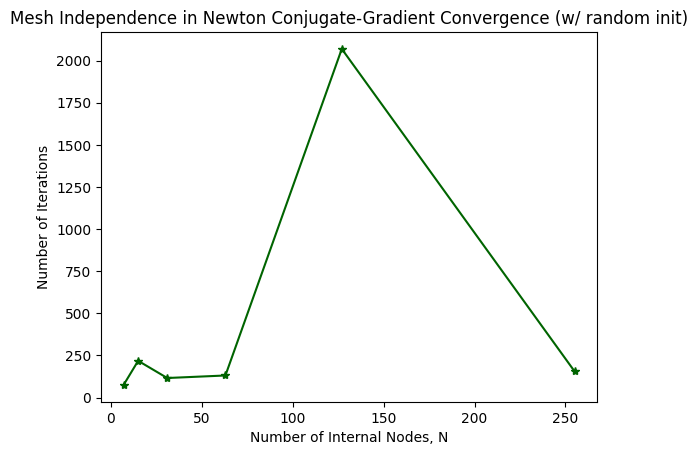

In [662]:

randniter = []
Ns = []
us=[]
sols = []
for p in range(6):
    N = 8*2**p - 1
    u = np.random.randn(N)
    niter, solval = ncg(u)
    randniter+=[niter]
    sols +=[solval]
    Ns += [N]
    us+=[u]
    print(p, niter)
plt.plot(Ns, randniter,"*-", color = "darkgreen")
plt.ylabel("Number of Iterations")
plt.xlabel("Number of Internal Nodes, N")
plt.title("Mesh Independence in Newton Conjugate-Gradient Convergence (w/ random init)")
print(randniter)

0 75
1 21
2 19
3 17
4 13
5 12


Text(0.5, 1.0, 'Mesh Independence in Newton Conjugate-Gradient Convergence (w/ random init + interpolation)')

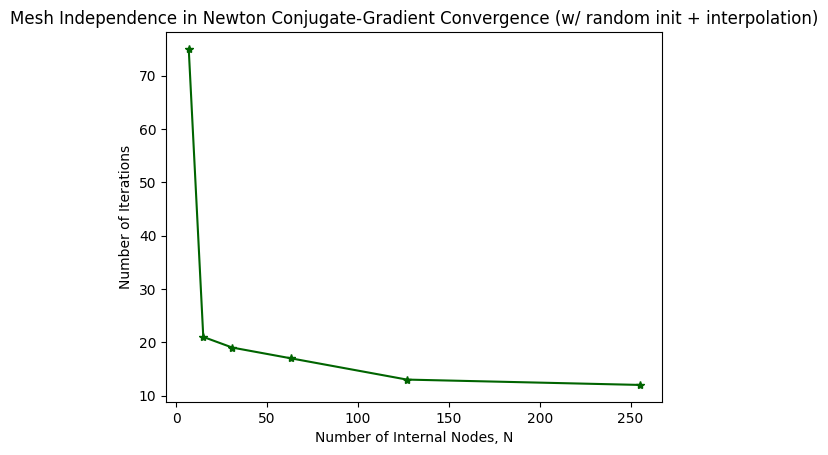

In [664]:

interpolate_iterations = []
Ns = []
for p in range(6):
    N = 8*2**p - 1
    if p ==0: # same random initialization
        u=us[0]
    else: # intrapolate u
        dh = 1/(Ns[-1]+1)
        new_dh = 1/(N+1)
        x_old = np.linspace(0+dh, 1-dh, len(solution))
        x_new = np.linspace(0+new_dh, 1-new_dh, N)
        u = np.interp(x_new, x_old, solution)

    solution, niter, njev = ncg_full(u)
    interpolate_iterations+=[niter]
    Ns += [N]
    print(p, niter)
plt.plot(Ns, interpolate_iterations,"*-", color = "darkgreen")
plt.ylabel("Number of Iterations")
plt.xlabel("Number of Internal Nodes, N")
plt.title("Mesh Independence in Newton Conjugate-Gradient Convergence (w/ random init + interpolation)")


In [665]:
print(interpolate_iterations)
np.cumsum(interpolate_iterations)

[75, 21, 19, 17, 13, 12]


array([ 75,  96, 115, 132, 145, 157])

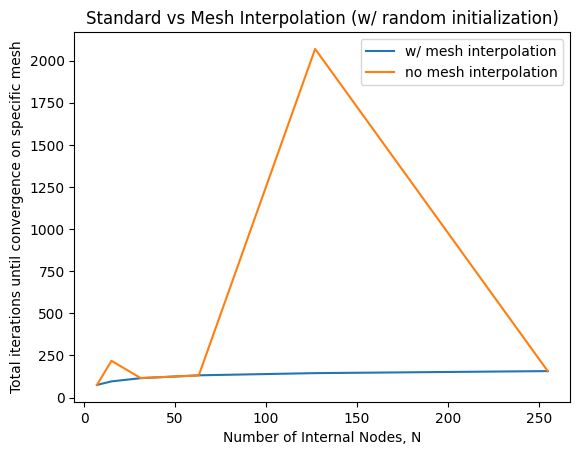

In [666]:
plt.plot(Ns, np.cumsum(interpolate_iterations), label = "w/ mesh interpolation")# with mesh interpolation, not cumsum
plt.plot(Ns, randniter, label = "no mesh interpolation")
plt.title("Standard vs Mesh Interpolation (w/ random initialization)")
plt.xlabel("Number of Internal Nodes, N")
plt.ylabel("Total iterations until convergence on specific mesh" )
plt.legend()
plt.show()

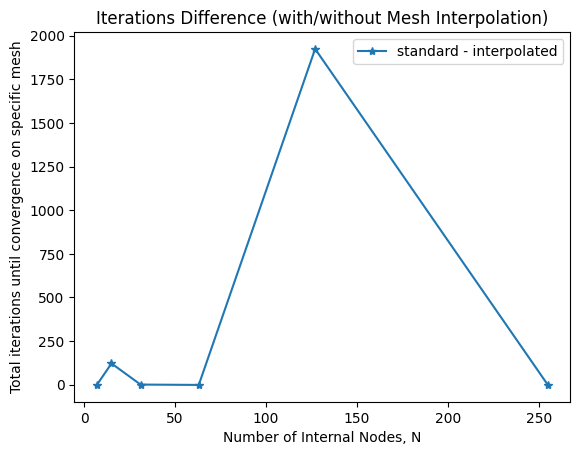

In [667]:
plt.plot(Ns, randniter-np.cumsum(interpolate_iterations), "*-", label = "standard - interpolated")# with mesh interpolation, not cumsum
plt.title("Iterations Difference (with/without Mesh Interpolation)")
plt.xlabel("Number of Internal Nodes, N")
plt.ylabel("Total iterations until convergence on specific mesh" )
plt.legend()
plt.show()

We see that as the mesh is refined more, mesh interpolative solutions (in general) become more efficient.

Per the above two graphs, we see that mesh interpolation is starting to help with convergence. For example, for $N= 64$, without interpolation, we require YYY iterations, while with interpolation, we can achieve convergence in XXX iterations. We can also try an "early Newton method stopping" algorithm.  

### Early Newton stopping
If the desired solution should be solved on a $N = 256$ grid, we can implement two "early stopping methods" while doing mesh refinement:
1) For the first few mesh sizes, we only need to find a solution that can work as a "good starting point." So, we can gradually increase the desired accuracy (and, likely, the number of Newton iterations) as the mesh size is refined further.
2) As standard, we keep our early CG stopping algorithm (further from the optimum, take a Newton step before complete CG convergence).

Refinement 0: N+1 = 8, Newton Tolerance = 1.0e-02, Newton Iterations = 5
Refinement 1: N+1 = 16, Newton Tolerance = 1.6e-03, Newton Iterations = 2
Refinement 2: N+1 = 32, Newton Tolerance = 2.5e-04, Newton Iterations = 24
Refinement 3: N+1 = 64, Newton Tolerance = 4.0e-05, Newton Iterations = 22
Refinement 4: N+1 = 128, Newton Tolerance = 6.3e-06, Newton Iterations = 58
Refinement 5: N+1 = 256, Newton Tolerance = 1.0e-06, Newton Iterations = 12


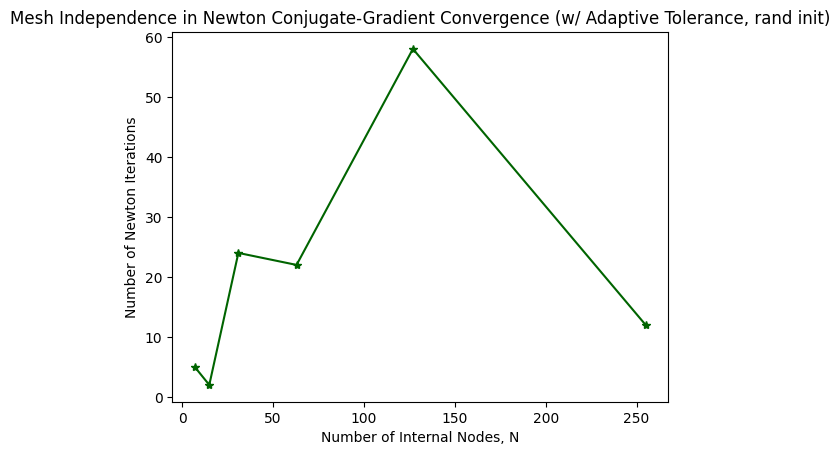

In [668]:
newton_early_interpolate_iterations = []
Ns = []
newton_tolerance = 1e-2  # Start with a loose tolerance
target_tolerance = 1e-6
num_refinements = 6
# reduction_factor = (target_tolerance / newton_tolerance) ** (1 / (num_refinements - 1))

for p in range(num_refinements):
    N = 8 * 2**p - 1  # Refining mesh size
    if p == 0:
        # Same random initialization for consistency
        u = us[0]
    else:
        # Interpolate solution to new mesh
        dh = 1 / (Ns[-1] + 1)
        new_dh = 1 / (N + 1)
        x_old = np.linspace(0 + dh, 1 - dh, len(solution))
        x_new = np.linspace(0 + new_dh, 1 - new_dh, N)
        u = np.interp(x_new, x_old, solution)

    newton_tolerance = 10**(-2 - (4 * p / (num_refinements - 1)))  # Ensures p=5 -> 1e-6
    solution, niter, njev = ncg_full(u, tolerance=newton_tolerance)

    newton_early_interpolate_iterations.append(niter)
    Ns.append(N)
    print(f"Refinement {p}: N+1 = {N+1}, Newton Tolerance = {newton_tolerance:.1e}, Newton Iterations = {niter}")

    # # Adjust reduction factor dynamically
    # if p < 2:
    #     newton_tolerance *= 10**-0.5  # Slower reduction
    # else:
    #     newton_tolerance *= 10**-0.8  # More aggressive reduction


plt.plot(Ns, newton_early_interpolate_iterations, "*-", color="darkgreen")
plt.ylabel("Number of Newton Iterations")
plt.xlabel("Number of Internal Nodes, N")
plt.title("Mesh Independence in Newton Conjugate-Gradient Convergence (w/ Adaptive Tolerance, rand init)")
plt.show()


In [669]:
np.sum(newton_early_interpolate_iterations)

123

For a mesh of $N+1 = 256$, convergence requires XXX iterations with early stopping Newton CG (and mesh interpolation), which is much better than the standard Newton CG's YY iterations.  

Refinement 0: N+1 = 8, Newton Tolerance = 1.0e-02, Newton Iterations = 3
Refinement 1: N+1 = 16, Newton Tolerance = 3.2e-03, Newton Iterations = 2
Refinement 2: N+1 = 32, Newton Tolerance = 1.0e-03, Newton Iterations = 2
Refinement 3: N+1 = 64, Newton Tolerance = 1.6e-04, Newton Iterations = 6
Refinement 4: N+1 = 128, Newton Tolerance = 2.5e-05, Newton Iterations = 41
Refinement 5: N+1 = 256, Newton Tolerance = 4.0e-06, Newton Iterations = 12


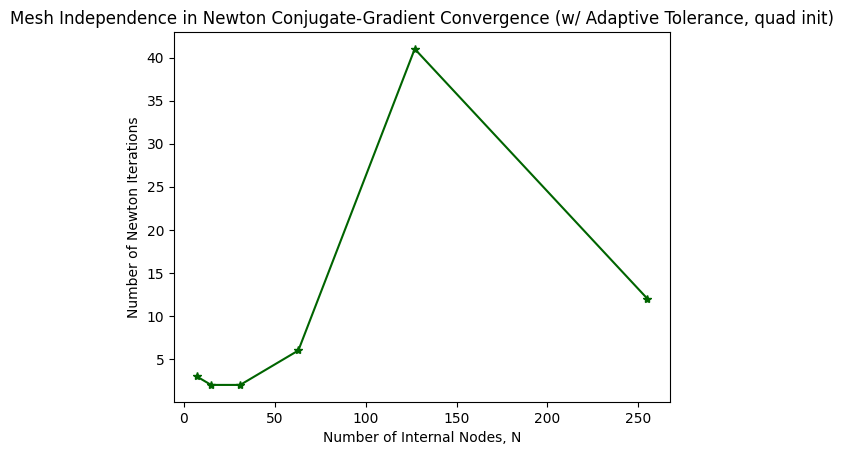

In [670]:
newton_early_interpolate_iterations = []
Ns = []
newton_tolerance = 1e-2  # Start with a loose tolerance
target_tolerance = 1e-6
num_refinements = 6
# reduction_factor = (target_tolerance / newton_tolerance) ** (1 / (num_refinements - 1))

for p in range(num_refinements):
    N = 8 * 2**p - 1  # Refining mesh size
    if p == 0:
        # Same random initialization for consistency
        u = u_init(N)
    else:
        # Interpolate solution to new mesh
        dh = 1 / (Ns[-1] + 1)
        new_dh = 1 / (N + 1)
        x_old = np.linspace(0 + dh, 1 - dh, len(solution))
        x_new = np.linspace(0 + new_dh, 1 - new_dh, N)
        u = np.interp(x_new, x_old, solution)

    # Solve with the current newton_tolerance
    solution, niter, njev = ncg_full(u, tolerance=newton_tolerance)

    newton_early_interpolate_iterations.append(niter)
    Ns.append(N)
    print(f"Refinement {p}: N+1 = {N+1}, Newton Tolerance = {newton_tolerance:.1e}, Newton Iterations = {niter}")

    # Adjust reduction factor dynamically
    if p < 2:
        newton_tolerance *= 10**-0.5  # Slower reduction
    else:
        newton_tolerance *= 10**-0.8  # More aggressive reduction

plt.plot(Ns, newton_early_interpolate_iterations, "*-", color="darkgreen")
plt.ylabel("Number of Newton Iterations")
plt.xlabel("Number of Internal Nodes, N")
plt.title("Mesh Independence in Newton Conjugate-Gradient Convergence (w/ Adaptive Tolerance, quad init)")
plt.show()


In [671]:
np.sum(newton_early_interpolate_iterations)

66

Even with early Newton stopping (and early CG stopping), mesh interpolation doesn't seem to improve convergence rates for highly refined meshes ($N +1 = 256$), when initialized with a quadratic solution (66 vs. ). As discussed earlier, this could be due to 1) a simple problem and/or 2) a too-good initialization.